In [128]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from tabulate import tabulate
from tqdm import tqdm
from pycoingecko import CoinGeckoAPI
from datetime import datetime
from scipy.stats import weibull_min

#####  A fazer: 

1. Trend stability
2. Support / resistance levels 
3. Implement ability to short

In [175]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from tabulate import tabulate
from tqdm import tqdm
from pycoingecko import CoinGeckoAPI
from datetime import datetime

class TrendAnalyzer:
    """
    A class to analyze price trends for multiple cryptocurrency assets, storing all data and classifications.

    Attributes:
        asset_ids (list): List of asset IDs to analyze
        data_path (str): Path to the directory containing candle data
        btc_data_path (str): Path to the Bitcoin data file
        use_btc_adjusted (bool): Whether to prioritize BTC-adjusted prices in output (default: True)
        verbose (bool): Whether to print detailed processing information (default: True)
        ticker_mapping (dict): Mapping from ticker symbols to asset IDs
        asset_data (dict): Dictionary storing raw data, indicators, classifications, and signals for each asset
        current_date (datetime): Current date for data currency validation
    """

    def __init__(self, asset_ids, data_path, btc_data_path, use_btc_adjusted=True, verbose=True):
        """
        Initialize the TrendAnalyzer with a list of asset IDs.

        Args:
            asset_ids (list): List of asset IDs to analyze
            data_path (str): Path to the directory containing candle data
            btc_data_path (str): Path to the Bitcoin data file
            use_btc_adjusted (bool): Whether to prioritize BTC-adjusted prices in output (default: True)
            verbose (bool): Whether to print detailed processing information (default: True)
        """
        self.asset_ids = asset_ids
        self.data_path = data_path
        self.btc_data_path = btc_data_path
        self.use_btc_adjusted = use_btc_adjusted
        self.verbose = verbose
        self.ma_periods = {
            'Short Term': [3, 5, 7, 14],
            'Medium Term': [21, 30, 45, 63],
            'Long Term': [84, 100, 120, 150, 200, 252, 365]
        }
        self.ticker_mapping = self._get_ticker_mapping()
        self.asset_data = {}  # Initialize state dictionary
        self.current_date = datetime(2025, 3, 11)  # Set current date as specified

    def _get_ticker_mapping(self):
        """
        Retrieve ticker mapping using CoinGecko API.

        Returns:
            dict: Mapping from ticker symbols (upper-case) to asset IDs
        """
        cg = CoinGeckoAPI()
        coins_list = cg.get_coins_list()
        coins_df = pd.DataFrame(coins_list)
        
        known_mappings = {
            'VIRTUAL': 'virtual-protocol',
            'HYPE': 'hyperliquid',
            'YNE': 'yesnoerror'
        }
        
        mapping = {}
        for ticker, coin_id in known_mappings.items():
            if coin_id in self.asset_ids:
                mapping[ticker] = coin_id
        
        filtered_coins_df = coins_df[coins_df['id'].isin(self.asset_ids)]
        for _, row in filtered_coins_df.iterrows():
            ticker = row['symbol'].upper()
            if ticker not in mapping:
                mapping[ticker] = row['id']
        
        return mapping

    def _load_data(self, asset_id):
        """
        Load and merge asset data with Bitcoin data if applicable.
        Also loads volume data from the assetData directory.

        Args:
            asset_id (str): Asset ID to load data for

        Returns:
            pd.DataFrame: Loaded and processed raw data, or empty DataFrame if file not found
        """
        # Load candle data from the primary path
        candle_data_path = f"{self.data_path}{asset_id}_candles.csv"
        try:
            data = pd.read_csv(candle_data_path)
        except FileNotFoundError:
            if self.verbose:
                print(f"Warning: File not found for {asset_id}: {candle_data_path}")
            return pd.DataFrame()
        
        data['date'] = pd.to_datetime(data['date'])
        data.dropna(inplace=True)
        
        # Load volume data from assetData folder
        volume_data_path = f"/Users/valter.rebelo/MissionControl/data/micro/assetData/{asset_id}.csv"
        try:
            # First check if the file has headers by reading the first row
            with open(volume_data_path, 'r') as f:
                first_line = f.readline().strip()
            
            # If first line contains 'date', it has headers
            if 'date' in first_line.lower():
                volume_data = pd.read_csv(volume_data_path)
            else:
                volume_data = pd.read_csv(volume_data_path, header=None, 
                                        names=['date', 'close_check', 'market_cap', 'total_volume'])
            
            volume_data['date'] = pd.to_datetime(volume_data['date'])
            # Keep only date and volume columns
            volume_data = volume_data[['date', 'total_volume']]
            # Merge volume data with candle data
            data = data.merge(volume_data, on='date', how='left')
            #if self.verbose:
            #    print(f"Added volume data for {asset_id} from {volume_data_path}")
        except FileNotFoundError:
            if self.verbose:
                print(f"Warning: Volume data not found for {asset_id}: {volume_data_path}")
        except Exception as e:
            if self.verbose:
                print(f"Error loading volume data for {asset_id}: {e}")
        
        # Process Bitcoin data as before
        if asset_id != 'bitcoin':
            btc_data = pd.read_csv(self.btc_data_path)
            btc_data['date'] = pd.to_datetime(btc_data['date'])
            btc_data = btc_data[['date', 'close']].rename(columns={'close': 'btc_close'})
            data = data.merge(btc_data, on='date', how='left')
            if 'close' in data.columns and 'btc_close' in data.columns:
                data[f'{asset_id}_btc'] = data['close'] / data['btc_close']
            data = data.drop(columns=['btc_close'], errors='ignore')

        return data

    def _calculate_indicators(self, data, price_column, asset_id, suffix=''):
        """
        Calculate Simple Moving Averages (SMAs) and Rate of Change (RoC) indicators for a given price column.

        Args:
            data (pd.DataFrame): DataFrame to calculate indicators for
            price_column (str): Name of the price column to use
            asset_id (str): Asset ID being processed
            suffix (str): Suffix to append to indicator column names (e.g., 'USD', 'BTC')
        """
        if price_column not in data.columns and not data.empty:
            raise KeyError(f"Column '{price_column}' not found for {asset_id}. Available columns: {list(data.columns)}")
        if not data.empty:
            data[price_column] = pd.to_numeric(data[price_column], errors='coerce')
            data.dropna(subset=[price_column], inplace=True)
            #if self.verbose:
            #    print(f"Columns after numeric conversion and dropna for {asset_id} ({price_column}): {list(data.columns)}")
            
            for term, periods in self.ma_periods.items():
                for period in periods:
                    data[f'SMA_{suffix}_{period}'] = data[price_column].rolling(
                        window=period, min_periods=period
                    ).mean()
            
            for term, periods in self.ma_periods.items():
                for period in periods:
                    data[f'RoC_{suffix}_{period}'] = (
                        (data[price_column] - data[price_column].shift(period))
                        / data[price_column].shift(period) * 100
                    )
            #if self.verbose:
            #    print(f"Columns after calculating indicators for {asset_id} ({suffix}): {list(data.columns)}")

    def classify_trend(self, mas, rocs, data, suffix):
        """
        Classify the trend based on moving averages and rate of change for a specific price column.

        Args:
            mas (pd.Series): Series of moving averages
            rocs (pd.Series): Series of rates of change
            data (pd.DataFrame): DataFrame containing the asset's price data
            suffix (str): Suffix indicating the price basis (e.g., 'USD', 'BTC')

        Returns:
            str: Trend classification ('Strong Bull', 'Weak Bull', 'Strong Bear', 'Weak Bear', 'Neutral')
        """
        n_mas = len(mas.dropna())
        n_rocs = len(rocs.dropna())
        if n_mas == 0 or n_rocs == 0:
            return "Neutral"
        
        pos_mas = 0
        for col in mas.index:
            period = int(col.replace(f'SMA_{suffix}_', ''))
            current_ma = data[f'SMA_{suffix}_{period}'].iloc[-1]
            prev_ma = data[f'SMA_{suffix}_{period}'].iloc[-2] if len(data) > 1 else np.nan
            if not np.isnan(current_ma) and not np.isnan(prev_ma) and current_ma > prev_ma:
                pos_mas += 1
        
        pos_mas = pos_mas / n_mas * 100 if n_mas > 0 else 0
        pos_rocs = sum(1 for roc in rocs if roc > 0) / n_rocs * 100 if n_rocs > 0 else 0
        
        avg_pos = (pos_mas + pos_rocs) / 2
        
        if avg_pos >= 75:
            return "Strong Bull"
        elif avg_pos >= 50:
            return "Weak Bull"
        elif avg_pos <= 25:
            return "Strong Bear"
        elif avg_pos <= 40:
            return "Weak Bear"
        return "Neutral"

    def _compute_overall_classification(self, trends):
        """
        Compute the overall trend classification based on individual timeframes.

        Args:
            trends (list): List of trend classifications for Short Term, Medium Term, and Long Term

        Returns:
            str: Overall trend classification
        """
        overall_pos = sum(1 for c in trends if c in ["Strong Bull", "Weak Bull"]) / len(trends) * 100
        if overall_pos >= 75:
            return "Strong Bull"
        elif overall_pos >= 50:
            return "Weak Bull"
        elif overall_pos <= 25:
            return "Strong Bear"
        elif overall_pos <= 40:
            return "Weak Bear"
        return "Neutral"

    def _compute_trend_duration(self, data, suffix):
        """
        Compute the duration of consecutive bullish trend classifications.
        
        Args:
            data (pd.DataFrame): DataFrame with trend classifications
            suffix (str): Price basis suffix (e.g., 'USD', 'BTC')
        
        Returns:
            pd.Series: Duration of consecutive bullish trends in days
        """
        durations = pd.Series(index=data.index, dtype=float)
        current_duration = 0
        last_classification = None
        
        for i in range(len(data)):
            classification = data[f'Overall ({suffix})'].iloc[i]
            if classification in ['Weak Bull', 'Strong Bull']:
                current_duration += 1
            else:
                current_duration = 0
            durations.iloc[i] = current_duration
            last_classification = classification
        
        return durations

    def _compute_trend_stability(self, durations, span=30):
        """
        Compute an Exponential Moving Average (EMA) of trend durations as a stability score.

        Args:
            durations (pd.Series): Series of consecutive bullish trend durations
            span (int): Smoothing span for the EMA (default: 30 days)

        Returns:
            pd.Series: Stability score based on the EMA of trend durations
        """
        # Use EMA to smooth trend durations, with a minimum period of 1 to avoid NaN
        stability_scores = durations.ewm(span=span, min_periods=1).mean()
        # Normalize the stability score by a threshold (e.g., 5 days) to range approximately 0 to 1
        stability_scores = stability_scores / 5.0
        return stability_scores

    def _create_classified_data(self, data, asset_id):
        """
        Create a DataFrame with historical trend classifications and stability scores.

        Args:
            data (pd.DataFrame): DataFrame with price and indicator data
            asset_id (str): Asset ID being processed

        Returns:
            pd.DataFrame: DataFrame with trend classifications and stability scores
        """
        if data.empty:
            return pd.DataFrame()
        classified_data = data.copy()

        # USD classifications
        usd_price_column = 'close'
        self._calculate_indicators(classified_data, usd_price_column, asset_id, suffix='USD')
        
        short_term_mas_usd = [f'SMA_USD_{period}' for period in self.ma_periods['Short Term']]
        medium_term_mas_usd = [f'SMA_USD_{period}' for period in self.ma_periods['Medium Term']]
        long_term_mas_usd = [f'SMA_USD_{period}' for period in self.ma_periods['Long Term']]
        
        short_term_rocs_usd = [f'RoC_USD_{period}' for period in self.ma_periods['Short Term']]
        medium_term_rocs_usd = [f'RoC_USD_{period}' for period in self.ma_periods['Medium Term']]
        long_term_rocs_usd = [f'RoC_USD_{period}' for period in self.ma_periods['Long Term']]

        classified_data['Short Term (USD)'] = classified_data.apply(
            lambda row: self.classify_trend(row[short_term_mas_usd], row[short_term_rocs_usd], classified_data, 'USD'), axis=1
        )
        classified_data['Medium Term (USD)'] = classified_data.apply(
            lambda row: self.classify_trend(row[medium_term_mas_usd], row[medium_term_rocs_usd], classified_data, 'USD'), axis=1
        )
        classified_data['Long Term (USD)'] = classified_data.apply(
            lambda row: self.classify_trend(row[long_term_mas_usd], row[long_term_rocs_usd], classified_data, 'USD'), axis=1
        )
        classified_data['Overall (USD)'] = classified_data.apply(
            lambda row: self._compute_overall_classification(
                [row['Short Term (USD)'], row['Medium Term (USD)'], row['Long Term (USD)']]
            ), axis=1
        )

        # BTC classifications (except for Bitcoin)
        if asset_id != 'bitcoin' and f'{asset_id}_btc' in classified_data.columns:
            btc_price_column = f'{asset_id}_btc'
            self._calculate_indicators(classified_data, btc_price_column, asset_id, suffix='BTC')
            
            short_term_mas_btc = [f'SMA_BTC_{period}' for period in self.ma_periods['Short Term']]
            medium_term_mas_btc = [f'SMA_BTC_{period}' for period in self.ma_periods['Medium Term']]
            long_term_mas_btc = [f'SMA_BTC_{period}' for period in self.ma_periods['Long Term']]
            
            short_term_rocs_btc = [f'RoC_BTC_{period}' for period in self.ma_periods['Short Term']]
            medium_term_rocs_btc = [f'RoC_BTC_{period}' for period in self.ma_periods['Medium Term']]
            long_term_rocs_btc = [f'RoC_BTC_{period}' for period in self.ma_periods['Long Term']]

            classified_data['Short Term (BTC)'] = classified_data.apply(
                lambda row: self.classify_trend(row[short_term_mas_btc], row[short_term_rocs_btc], classified_data, 'BTC'), axis=1
            )
            classified_data['Medium Term (BTC)'] = classified_data.apply(
                lambda row: self.classify_trend(row[medium_term_mas_btc], row[medium_term_rocs_btc], classified_data, 'BTC'), axis=1
            )
            classified_data['Long Term (BTC)'] = classified_data.apply(
                lambda row: self.classify_trend(row[long_term_mas_btc], row[long_term_rocs_btc], classified_data, 'BTC'), axis=1
            )
            classified_data['Overall (BTC)'] = classified_data.apply(
                lambda row: self._compute_overall_classification(
                    [row['Short Term (BTC)'], row['Medium Term (BTC)'], row['Long Term (BTC)']]
                ), axis=1
            )
        else:
            classified_data['Short Term (BTC)'] = pd.NA
            classified_data['Medium Term (BTC)'] = pd.NA
            classified_data['Long Term (BTC)'] = pd.NA
            classified_data['Overall (BTC)'] = pd.NA
        
        # Add trend duration and EMA-based stability score
        classified_data['Trend_Duration_USD'] = self._compute_trend_duration(classified_data, 'USD')
        classified_data['Stability_Score_USD'] = self._compute_trend_stability(classified_data['Trend_Duration_USD'])
        
        if asset_id != 'bitcoin' and f'{asset_id}_btc' in classified_data.columns:
            classified_data['Trend_Duration_BTC'] = self._compute_trend_duration(classified_data, 'BTC')
            classified_data['Stability_Score_BTC'] = self._compute_trend_stability(classified_data['Trend_Duration_BTC'])
        else:
            classified_data['Trend_Duration_BTC'] = pd.NA
            classified_data['Stability_Score_BTC'] = pd.NA
        
        return classified_data

    def analyze(self, asset_id, data, suffix):
        """
        Analyze trends for a single asset using a specific price suffix.

        Args:
            asset_id (str): Asset ID to analyze
            data (pd.DataFrame): DataFrame containing price data
            suffix (str): Suffix indicating the price basis (e.g., 'USD', 'BTC')

        Returns:
            dict: Dictionary of trend classifications for Short Term, Medium Term, Long Term, and Overall
        """
        if data.empty:
            return {'Short Term': 'N/A', 'Medium Term': 'N/A', 'Long Term': 'N/A', 'Overall': 'N/A'}
        classifications = {}
        for term in ['Short Term', 'Medium Term', 'Long Term']:
            classifications[term] = data[f'{term} ({suffix})'].iloc[-1]
        classifications['Overall'] = data[f'Overall ({suffix})'].iloc[-1]
        if self.verbose:
            for term, classification in classifications.items():
                print(f"{term} classification for {asset_id} ({suffix}): {classification}")
        return classifications

    def create_chart(self, asset_id, data, price_column):
        """
        Create a Plotly chart of price and SMAs for a single asset.

        Args:
            asset_id (str): Asset ID to create chart for
            data (pd.DataFrame): DataFrame containing price and SMA data
            price_column (str): Name of the price column to plot

        Returns:
            go.Figure: Plotly figure object, or None if no data
        """
        if data.empty:
            if self.verbose:
                print(f"No data available to create chart for {asset_id} ({price_column})")
            return None
        selected_smas = [14, 30, 63, 200]
        suffix = 'USD' if price_column == 'close' else 'BTC'
        fig = go.Figure()

        fig.add_trace(go.Scatter(
            x=data['date'],
            y=data[price_column],
            mode='lines',
            name='Price',
            line=dict(color='green'),
            yaxis='y1'
        ))

        colors = ['red', 'orange', 'purple', 'gray']
        for i, period in enumerate(selected_smas):
            fig.add_trace(go.Scatter(
                x=data['date'],
                y=data[f'SMA_{suffix}_{period}'],
                mode='lines',
                name=f'SMA{period}',
                line=dict(color=colors[i % len(colors)], width=2),
                yaxis='y1'
            ))

        fig.update_layout(
            title=f"{asset_id.upper()} Price and SMAs ({suffix})",
            xaxis_title="Date",
            yaxis_title=f"Price ({suffix})",
            yaxis=dict(type='log', autorange=True, gridcolor='lightgray'),
            xaxis=dict(gridcolor='lightgray'),
            template="plotly_white",
            showlegend=True,
            height=500,
            margin=dict(l=50, r=50, t=100, b=50)
        )
        return fig

    def analyze_multiple_assets(self):
        """
        Analyze trends for all assets, store data in state, and output a consolidated table using ticker symbols.

        Returns:
            pd.DataFrame: DataFrame containing the most recent trend analysis for all assets
        """
        self.asset_data = {}  # Initialize state dictionary
        results = []
        reverse_mapping = {v: k for k, v in self.ticker_mapping.items()}
        
        for asset_id in tqdm(self.asset_ids, desc="Analyzing assets", disable=not self.verbose):
            # Load raw data
            raw_data = self._load_data(asset_id)
            
            # Process classifications for both USD and BTC in a single DataFrame
            classified_data = self._create_classified_data(raw_data, asset_id)

            # Store all data in state
            self.asset_data[asset_id] = {
                'raw_data': raw_data.copy(),
                'classified_data': classified_data.copy(),
                'price_column_usd': 'close',
                'price_column_btc': f'{asset_id}_btc' if asset_id != 'bitcoin' and f'{asset_id}_btc' in classified_data.columns else None
            }

            # Get the most recent classifications
            latest_classifications = classified_data.iloc[-1].to_dict() if not classified_data.empty else {
                'Short Term (USD)': 'N/A',
                'Medium Term (USD)': 'N/A',
                'Long Term (USD)': 'N/A',
                'Overall (USD)': 'N/A',
                'Short Term (BTC)': 'N/A',
                'Medium Term (BTC)': 'N/A',
                'Long Term (BTC)': 'N/A',
                'Overall (BTC)': 'N/A'
            }

            ticker = reverse_mapping.get(asset_id, asset_id.upper())
            results.append({
                'Ticker': ticker,
                'Short Term Trend (USD)': latest_classifications.get('Short Term (USD)', 'N/A'),
                'Medium Term Trend (USD)': latest_classifications.get('Medium Term (USD)', 'N/A'),
                'Long Term Trend (USD)': latest_classifications.get('Long Term (USD)', 'N/A'),
                'Overall Trend (USD)': latest_classifications.get('Overall (USD)', 'N/A'),
                'Short Term Trend (BTC)': latest_classifications.get('Short Term (BTC)', 'N/A'),
                'Medium Term Trend (BTC)': latest_classifications.get('Medium Term (BTC)', 'N/A'),
                'Long Term Trend (BTC)': latest_classifications.get('Long Term (BTC)', 'N/A'),
                'Overall Trend (BTC)': latest_classifications.get('Overall (BTC)', 'N/A'),
                'Latest Date': classified_data['date'].iloc[-1].date() if not classified_data.empty else None
            })

        summary_df = pd.DataFrame(results)
        
        if self.verbose:
            print("\nMost Recent Trend Analysis Summary for Multiple Assets (as of March 11, 2025):")
            print(tabulate(summary_df, headers='keys', tablefmt='pretty', showindex=False))
        
        return summary_df

# Usage
if __name__ == "__main__":
    from scripts.assetsRoster import carteira_AC, carteira_HB, carteira_LC, carteira_EXC, others

    # Combine all unique assets from the portfolio
    all_assets = list(set(carteira_AC+others))
    
    analyzer = TrendAnalyzer(
        asset_ids=all_assets,
        data_path='/Users/valter.rebelo/MissionControl/data/micro/candleData/',
        btc_data_path='/Users/valter.rebelo/MissionControl/data/micro/assetData/bitcoin.csv',
        use_btc_adjusted=False,
        verbose=True
    )
    summary_df = analyzer.analyze_multiple_assets()

    # Example access to stored data with unified DataFrame
    for asset_id in all_assets:
        if asset_id in analyzer.asset_data:
            print(f"\nUnified Classified Data for {asset_id}:")
            print(analyzer.asset_data[asset_id]['classified_data'].tail())

Analyzing assets: 100%|██████████| 30/30 [00:52<00:00,  1.76s/it]


Most Recent Trend Analysis Summary for Multiple Assets (as of March 11, 2025):
+----------+------------------------+-------------------------+-----------------------+---------------------+------------------------+-------------------------+-----------------------+---------------------+-------------+
|  Ticker  | Short Term Trend (USD) | Medium Term Trend (USD) | Long Term Trend (USD) | Overall Trend (USD) | Short Term Trend (BTC) | Medium Term Trend (BTC) | Long Term Trend (BTC) | Overall Trend (BTC) | Latest Date |
+----------+------------------------+-------------------------+-----------------------+---------------------+------------------------+-------------------------+-----------------------+---------------------+-------------+
|  AIXBT   |      Strong Bear       |       Strong Bear       |      Strong Bear      |     Strong Bear     |      Strong Bear       |       Strong Bear       |      Strong Bear      |     Strong Bear     | 2025-03-11  |
|   USDC   |      Strong Bear       

In [182]:
alt_trend = analyzer.asset_data.get('chainlink').get('classified_data')[['date', 'close', 'open', 'Overall (BTC)', 'Overall (USD)', 'Short Term (BTC)', 'Short Term (USD)', 'Medium Term (BTC)', 'Medium Term (USD)', 'Long Term (BTC)', 'Long Term (USD)', 'Trend_Duration_USD', 'Stability_Score_USD', 'Trend_Duration_BTC',
       'Stability_Score_BTC']]
alt_trend = alt_trend.rename(columns={'date': 'Date'})
alt_trend


,Date,close,open,Overall (BTC),Overall (USD),Short Term (BTC),Short Term (USD),Medium Term (BTC),Medium Term (USD),Long Term (BTC),Long Term (USD),Trend_Duration_USD,Stability_Score_USD,Trend_Duration_BTC,Stability_Score_BTC
0,2017-11-10,0.225377,0.225377,Strong Bear,Strong Bear,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,0.0,0.000000,0.0,0.000000
1,2017-11-11,0.189036,0.189036,Strong Bear,Strong Bear,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,0.0,0.000000,0.0,0.000000
2,2017-11-12,0.181223,0.181223,Strong Bear,Strong Bear,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,0.0,0.000000,0.0,0.000000
3,2017-11-13,0.170013,0.170013,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Neutral,Neutral,Neutral,Neutral,0.0,0.000000,0.0,0.000000
4,2017-11-14,0.180691,0.180691,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Neutral,Neutral,Neutral,Neutral,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2674,2025-03-07,17.090000,16.470000,Weak Bear,Strong Bear,Weak Bull,Weak Bear,Strong Bear,Strong Bear,Weak Bear,Neutral,0.0,0.053919,0.0,0.002299
2675,2025-03-08,15.960000,17.050000,Strong Bear,Strong Bear,Weak Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Neutral,0.0,0.050441,0.0,0.002151
2676,2025-03-09,15.240000,15.940000,Weak Bear,Strong Bear,Weak Bull,Strong Bear,Strong Bear,Strong Bear,Weak Bear,Neutral,0.0,0.047186,0.0,0.002012
2677,2025-03-10,13.780000,15.250000,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Weak Bear,0.0,0.044142,0.0,0.001882


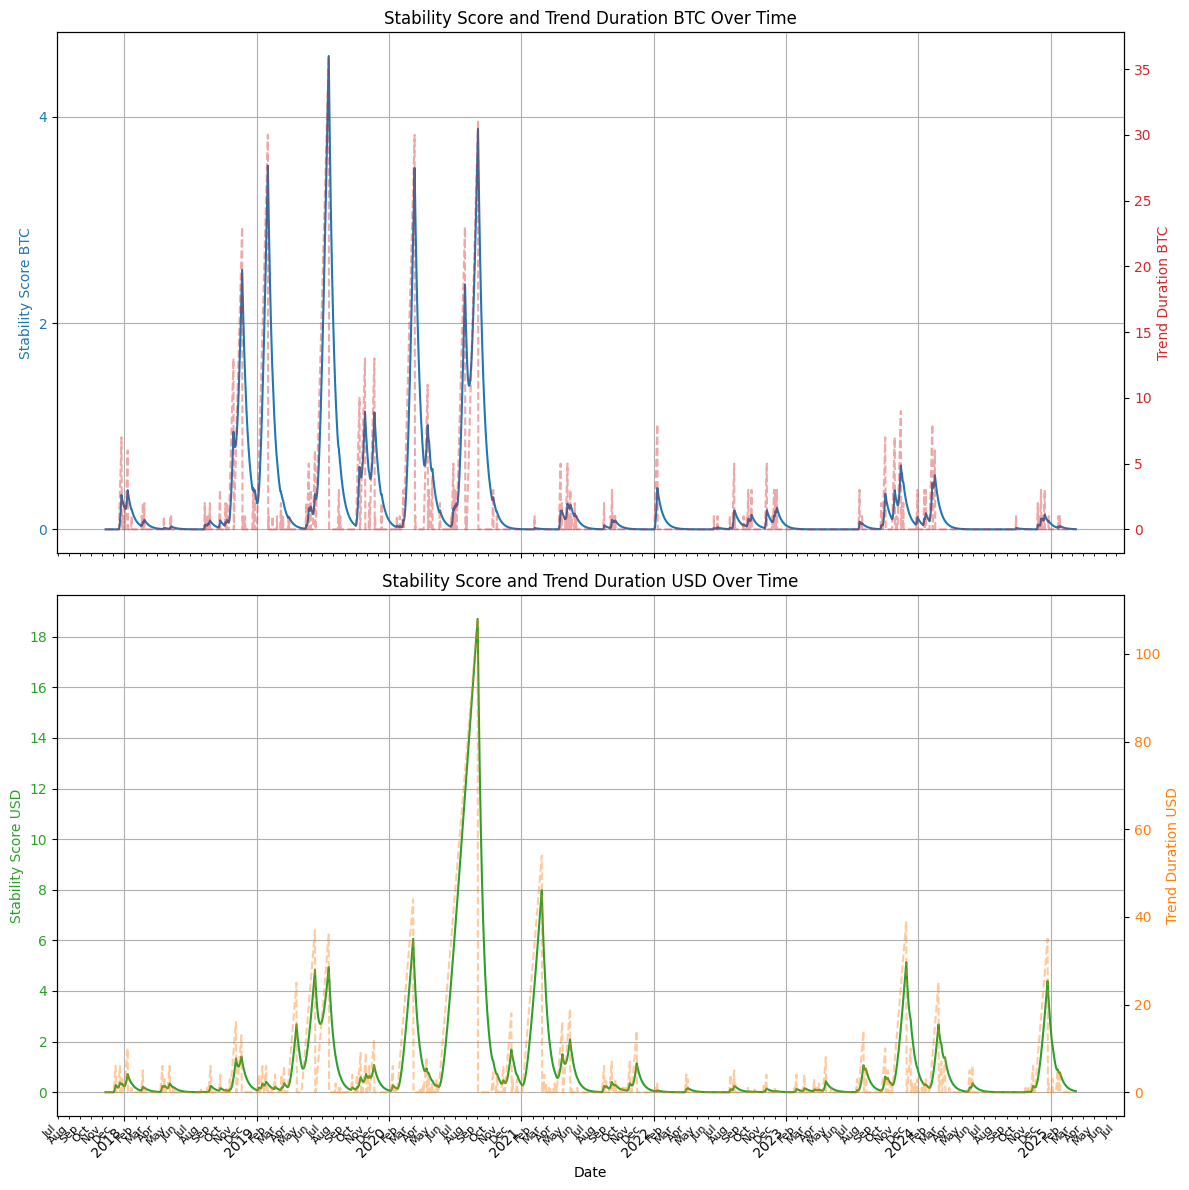

In [184]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.dates import MonthLocator, YearLocator, DateFormatter

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# Plot Stability Score BTC with dual axis for Trend Duration BTC
color1 = 'tab:blue'
ax1.plot(alt_trend['Date'], alt_trend['Stability_Score_BTC'], color=color1)
ax1.set_ylabel('Stability Score BTC', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_title('Stability Score and Trend Duration BTC Over Time')
ax1.grid(True)
ax1.set_yticks(np.arange(0, alt_trend['Stability_Score_BTC'].max() + 1, 2))

# Create a second y-axis for Trend Duration BTC
ax1_twin = ax1.twinx()
color2 = 'tab:red'
ax1_twin.plot(alt_trend['Date'], alt_trend['Trend_Duration_BTC'], color=color2, linestyle='dashed', alpha=0.4)
ax1_twin.set_ylabel('Trend Duration BTC', color=color2)
ax1_twin.tick_params(axis='y', labelcolor=color2)

# Plot Stability Score USD with dual axis for Trend Duration USD
color3 = 'tab:green'
ax2.plot(alt_trend['Date'], alt_trend['Stability_Score_USD'], color=color3)
ax2.set_xlabel('Date')
ax2.set_ylabel('Stability Score USD', color=color3)
ax2.tick_params(axis='y', labelcolor=color3)
ax2.set_title('Stability Score and Trend Duration USD Over Time')
ax2.grid(True)
ax2.set_yticks(np.arange(0, alt_trend['Stability_Score_USD'].max() + 1, 2))

# Create a second y-axis for Trend Duration USD
ax2_twin = ax2.twinx()
color4 = 'tab:orange'
ax2_twin.plot(alt_trend['Date'], alt_trend['Trend_Duration_USD'], color=color4, linestyle='dashed', alpha=0.4)
ax2_twin.set_ylabel('Trend Duration USD', color=color4)
ax2_twin.tick_params(axis='y', labelcolor=color4)

# Set up the x-axis to show every month and year for both subplots
ax2.xaxis.set_major_locator(YearLocator())
ax2.xaxis.set_major_formatter(DateFormatter('%Y'))
ax2.xaxis.set_minor_locator(MonthLocator())
ax2.xaxis.set_minor_formatter(DateFormatter('%b'))

# Format the tick labels
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax2.get_xminorticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()


In [185]:
btc_dom = pd.read_csv('/Users/valter.rebelo/MissionControl/data/micro/marketData/btc_dominance.csv')
btc_dom.rename(columns={'date': 'Date'}, inplace=True)
btc_dom['Date'] = pd.to_datetime(btc_dom['Date'])
btc_dom

,Date,btc_dominance
0,2013-04-29,0.903828
1,2013-04-30,0.815532
2,2013-05-01,0.833150
3,2013-05-02,0.828225
4,2013-05-03,1.149855
...,...,...
4308,2025-03-07,0.564401
4309,2025-03-08,0.579210
4310,2025-03-09,0.545558
4311,2025-03-10,0.569746


In [186]:
btc_strategy = pd.read_csv('hmm_btc_strategy_12_03_2025.csv')[['Date','state', 'Close']]
btc_strategy.rename(columns={'state': 'btc_state', 'Close': 'btc_close'}, inplace=True)
btc_strategy

,Date,btc_state,btc_close
0,2024-04-06,Flat,67979.0
1,2024-04-07,Long,69001.0
2,2024-04-08,Long,69402.0
3,2024-04-09,Long,71624.0
4,2024-04-10,Long,69159.0
...,...,...,...
335,2025-03-07,Flat,90001.0
336,2025-03-08,Flat,86773.0
337,2025-03-09,Flat,86143.0
338,2025-03-10,Flat,80751.0


In [187]:
# Convert the Date column in btc_strategy to datetime
btc_strategy['Date'] = pd.to_datetime(btc_strategy['Date'])

# Now merge the dataframes with matching date types
data = pd.merge(alt_trend, btc_strategy, on='Date', how='inner')
data = pd.merge(data, btc_dom, on='Date', how='inner')

#data['dom_roc'] = (data['btc_dominance'] - data['btc_dominance'].shift(3)) / data['btc_dominance'].shift(3) * 100

data


,Date,close,open,Overall (BTC),Overall (USD),Short Term (BTC),Short Term (USD),Medium Term (BTC),Medium Term (USD),Long Term (BTC),Long Term (USD),Trend_Duration_USD,Stability_Score_USD,Trend_Duration_BTC,Stability_Score_BTC,btc_state,btc_close,btc_dominance
0,2024-04-06,17.34,17.79,Strong Bear,Weak Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Weak Bull,0.0,0.322761,0.0,0.018689,Flat,67979.0,0.512863
1,2024-04-07,17.56,17.32,Strong Bear,Weak Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Weak Bull,0.0,0.301938,0.0,0.017483,Long,69001.0,0.508266
2,2024-04-08,17.92,17.57,Strong Bear,Weak Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Weak Bull,0.0,0.282458,0.0,0.016355,Long,69402.0,0.517820
3,2024-04-09,18.09,17.92,Strong Bear,Weak Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Weak Bull,0.0,0.264235,0.0,0.015300,Long,71624.0,0.482330
4,2024-04-10,17.36,18.10,Strong Bear,Weak Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Weak Bull,0.0,0.247187,0.0,0.014313,Long,69159.0,0.510515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,2025-03-07,17.09,16.47,Weak Bear,Strong Bear,Weak Bull,Weak Bear,Strong Bear,Strong Bear,Weak Bear,Neutral,0.0,0.053919,0.0,0.002299,Flat,90001.0,0.564401
336,2025-03-08,15.96,17.05,Strong Bear,Strong Bear,Weak Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Neutral,0.0,0.050441,0.0,0.002151,Flat,86773.0,0.579210
337,2025-03-09,15.24,15.94,Weak Bear,Strong Bear,Weak Bull,Strong Bear,Strong Bear,Strong Bear,Weak Bear,Neutral,0.0,0.047186,0.0,0.002012,Flat,86143.0,0.545558
338,2025-03-10,13.78,15.25,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Strong Bear,Weak Bear,0.0,0.044142,0.0,0.001882,Flat,80751.0,0.569746


In [202]:
def combined_strategy_backtest(data, initial_investment=1000, risk_free_rate=0.0, min_stability=1.1):
    """
    Hybrid trading strategy using trend stability for entry and exit decisions.

    - Follows the BTC HMM strategy (go long BTC when HMM says "Long", otherwise stay in cash).
    - For altcoin exposure, enters a 50-50 BTC/altcoin position when:
        - Momentum conditions are met (Short Term USD and BTC are bullish, and either Medium or Long Term USD is bullish).
        - BTC HMM state is "Long".
        - Stability score (Stability_Score_USD) exceeds the minimum threshold (min_stability).
        - The strategy is not already in an altcoin position (in_position = False).
    - Continues holding the altcoin position if:
        - Momentum conditions are still met.
        - Stability score exceeds the minimum threshold.
    - Exits the altcoin position (sets alt_signal to 0) if either:
        - Momentum conditions are no longer met.
        - Stability score drops below the minimum threshold.
    - If not in an altcoin position but BTC HMM state is "Long", allocates 100% to BTC.

    Args:
        data (pd.DataFrame): DataFrame with trend classifications, price data, BTC state, and stability scores
        initial_investment (float): Initial portfolio value (default: $1000)
        risk_free_rate (float): Annual risk-free rate (default: 0.0)
        min_stability (float): Minimum stability score for entry and holding (default: 0.5)

    Returns:
        pd.DataFrame: DataFrame with strategy signals and performance metrics
    """
    # Create a copy of the data to avoid modifying the original
    strategy_data = data.copy()
    
    # Create a BTC signal column (1 when HMM says Long, 0 otherwise)
    strategy_data['btc_signal'] = 0
    strategy_data.loc[strategy_data['btc_state'] == 'Long', 'btc_signal'] = 1
    
    # Define momentum conditions for altcoin strategy
    strategy_conditions = (
        ((strategy_data['Short Term (USD)'].isin(['Weak Bull', 'Strong Bull'])) & 
         (strategy_data['Short Term (BTC)'].isin(['Weak Bull', 'Strong Bull']))) &
        (strategy_data['Long Term (USD)'].isin(['Weak Bull', 'Strong Bull']) | 
         (strategy_data['Medium Term (USD)'].isin(['Weak Bull', 'Strong Bull']))) &
        (strategy_data['btc_state'] == 'Long')
    )
    
    # Add stability filter for entry and holding
    strategy_data['stability_confirmed'] = strategy_data['Stability_Score_USD'] >= min_stability
    
    # Initialize alt_signal and track position
    strategy_data['alt_signal'] = 0
    strategy_data['in_position'] = False  # Track whether we're in an altcoin position
    
    # Decision logic using momentum and stability for entry and exit
    for i in range(1, len(strategy_data)):
        # If not in position, check for entry
        if not strategy_data['in_position'].iloc[i-1]:
            if (strategy_conditions.iloc[i] and 
                strategy_data['stability_confirmed'].iloc[i]):
                strategy_data.loc[strategy_data.index[i], 'alt_signal'] = 1
                strategy_data.loc[strategy_data.index[i], 'in_position'] = True
        # If in position, continue holding if momentum and stability conditions are met
        elif (strategy_conditions.iloc[i] and 
              strategy_data['stability_confirmed'].iloc[i]):
            strategy_data.loc[strategy_data.index[i], 'alt_signal'] = 1
            strategy_data.loc[strategy_data.index[i], 'in_position'] = True
        # Exit if either momentum or stability conditions fail
        else:
            strategy_data.loc[strategy_data.index[i], 'alt_signal'] = 0
            strategy_data.loc[strategy_data.index[i], 'in_position'] = False
    
    # Calculate daily returns
    strategy_data['daily_return'] = strategy_data['close'].pct_change()
    strategy_data['btc_daily_return'] = strategy_data['btc_close'].pct_change()
    
    # Calculate strategy returns with a 1-day lag to avoid look-ahead bias
    # BTC strategy returns
    strategy_data['btc_strategy_return'] = strategy_data['btc_signal'].shift(1) * strategy_data['btc_daily_return']
    
    # Alt-only strategy returns
    strategy_data['alt_strategy_return'] = strategy_data['alt_signal'].shift(1) * strategy_data['daily_return']
    
    # Calculate hybrid strategy returns:
    # - When alt_signal is 1, allocate 50% to alt and 50% to BTC
    # - When alt_signal is 0 but btc_signal is 1, allocate 100% to BTC
    # - When both signals are 0, stay in cash (0% return)
    strategy_data['hybrid_return'] = 0.0
    
    # Case 1: When alt_signal is active, invest 50-50
    alt_signal_active = strategy_data['alt_signal'].shift(1) == 1
    strategy_data.loc[alt_signal_active, 'hybrid_return'] = (
        0.5 * strategy_data.loc[alt_signal_active, 'daily_return'] + 
        0.5 * strategy_data.loc[alt_signal_active, 'btc_daily_return']
    )
    
    # Case 2: When only BTC signal is active, invest 100% in BTC
    btc_only_active = (strategy_data['alt_signal'].shift(1) == 0) & (strategy_data['btc_signal'].shift(1) == 1)
    strategy_data.loc[btc_only_active, 'hybrid_return'] = strategy_data.loc[btc_only_active, 'btc_daily_return']
    
    # Calculate portfolio values
    strategy_data['buy_hold_value'] = initial_investment * (1 + strategy_data['daily_return']).cumprod()
    strategy_data['btc_value'] = initial_investment * (1 + strategy_data['btc_daily_return']).cumprod()
    strategy_data['btc_strategy_value'] = initial_investment * (1 + strategy_data['btc_strategy_return']).cumprod()
    strategy_data['alt_strategy_value'] = initial_investment * (1 + strategy_data['alt_strategy_return']).cumprod()
    strategy_data['hybrid_strategy_value'] = initial_investment * (1 + strategy_data['hybrid_return']).cumprod()
    
    # Correctly calculate drawdowns
    strategy_data['buy_hold_peak'] = strategy_data['buy_hold_value'].cummax()
    strategy_data['btc_peak'] = strategy_data['btc_value'].cummax()
    strategy_data['btc_strategy_peak'] = strategy_data['btc_strategy_value'].cummax()
    strategy_data['alt_strategy_peak'] = strategy_data['alt_strategy_value'].cummax()
    strategy_data['hybrid_strategy_peak'] = strategy_data['hybrid_strategy_value'].cummax()
    
    strategy_data['buy_hold_drawdown'] = (strategy_data['buy_hold_value'] - strategy_data['buy_hold_peak']) / strategy_data['buy_hold_peak']
    strategy_data['btc_drawdown'] = (strategy_data['btc_value'] - strategy_data['btc_peak']) / strategy_data['btc_peak']
    strategy_data['btc_strategy_drawdown'] = (strategy_data['btc_strategy_value'] - strategy_data['btc_strategy_peak']) / strategy_data['btc_strategy_peak']
    strategy_data['alt_strategy_drawdown'] = (strategy_data['alt_strategy_value'] - strategy_data['alt_strategy_peak']) / strategy_data['alt_strategy_peak']
    strategy_data['hybrid_strategy_drawdown'] = (strategy_data['hybrid_strategy_value'] - strategy_data['hybrid_strategy_peak']) / strategy_data['hybrid_strategy_peak']
    
    return strategy_data

# Run the backtest with initial investment of $1000
initial_investment = 1000
risk_free_rate = 0.0  # Assuming 0% risk-free rate for crypto
backtest_results = combined_strategy_backtest(data, initial_investment, risk_free_rate)

# Calculate Sharpe and Sortino ratios
def calculate_risk_metrics(returns, risk_free_rate=0.0):
    """Calculate Sharpe and Sortino ratios for a series of returns"""
    returns = returns.dropna()
    if len(returns) == 0 or returns.std() == 0:
        return 0, 0
    daily_rf_rate = (1 + risk_free_rate) ** (1/365) - 1
    excess_returns = returns - daily_rf_rate
    sharpe_ratio = np.sqrt(365) * excess_returns.mean() / excess_returns.std()
    downside_returns = excess_returns[excess_returns < 0]
    sortino_ratio = np.sqrt(365) * excess_returns.mean() / downside_returns.std() if len(downside_returns) > 0 and downside_returns.std() > 0 else np.inf
    return sharpe_ratio, sortino_ratio

# Calculate risk metrics for all approaches
buy_hold_sharpe, buy_hold_sortino = calculate_risk_metrics(backtest_results['daily_return'].dropna(), risk_free_rate)
btc_sharpe, btc_sortino = calculate_risk_metrics(backtest_results['btc_daily_return'].dropna(), risk_free_rate)
btc_strategy_sharpe, btc_strategy_sortino = calculate_risk_metrics(backtest_results['btc_strategy_return'].dropna(), risk_free_rate)
alt_strategy_sharpe, alt_strategy_sortino = calculate_risk_metrics(backtest_results['alt_strategy_return'].dropna(), risk_free_rate)
hybrid_sharpe, hybrid_sortino = calculate_risk_metrics(backtest_results['hybrid_return'].dropna(), risk_free_rate)

# Visualize the strategy performance with portfolio values
fig = px.line(backtest_results, x='Date', 
             y=['buy_hold_value', 'btc_value', 'btc_strategy_value', 'alt_strategy_value', 'hybrid_strategy_value'],
             title='Hybrid Strategy Backtest Performance (with Volume Ratio for Entry)',
             labels={'value': 'Portfolio Value ($)', 'variable': 'Strategy'},
             color_discrete_map={
                 'buy_hold_value': 'gray',
                 'btc_value': 'orange',
                 'btc_strategy_value': 'blue',
                 'alt_strategy_value': 'red',
                 'hybrid_strategy_value': 'green'
             })

fig.update_layout(
    xaxis_title='',
    yaxis_title='Portfolio Value ($)',
    template='plotly_white',
    height=600,
    width=1000,
    legend=dict(
        title=None,
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    )
)

fig.for_each_trace(lambda t: t.update(
    name={
        'buy_hold_value': 'Alt Buy & Hold',
        'btc_value': 'BTC Buy & Hold',
        'btc_strategy_value': 'BTC HMM Strategy',
        'alt_strategy_value': 'Alt-only Strategy',
        'hybrid_strategy_value': 'Hybrid Strategy (BTC/50-50)'
    }[t.name]
))

fig.show()

# Calculate percentage of time in market
total_days = len(backtest_results)
alt_invested_days = backtest_results['alt_signal'].sum()
btc_invested_days = backtest_results['btc_signal'].sum()
hybrid_both_days = ((backtest_results['alt_signal'] == 1) & (backtest_results['btc_signal'] == 1)).sum()
hybrid_btc_only_days = ((backtest_results['alt_signal'] == 0) & (backtest_results['btc_signal'] == 1)).sum()
hybrid_total_days = hybrid_both_days + hybrid_btc_only_days

alt_percent_invested = alt_invested_days / total_days * 100
btc_percent_invested = btc_invested_days / total_days * 100
hybrid_percent_invested = hybrid_total_days / total_days * 100
percent_5050_allocation = hybrid_both_days / hybrid_total_days * 100 if hybrid_total_days > 0 else 0

# Calculate total and annualized returns
days_in_market = (backtest_results['Date'].iloc[-1] - backtest_results['Date'].iloc[0]).days
annual_factor = 365 / days_in_market

final_buy_hold_value = backtest_results['buy_hold_value'].iloc[-1]
final_btc_value = backtest_results['btc_value'].iloc[-1]
final_btc_strategy_value = backtest_results['btc_strategy_value'].iloc[-1]
final_alt_strategy_value = backtest_results['alt_strategy_value'].iloc[-1]
final_hybrid_value = backtest_results['hybrid_strategy_value'].iloc[-1]

buy_hold_return = (final_buy_hold_value / initial_investment) - 1
btc_return = (final_btc_value / initial_investment) - 1
btc_strategy_return = (final_btc_strategy_value / initial_investment) - 1
alt_strategy_return = (final_alt_strategy_value / initial_investment) - 1
hybrid_return = (final_hybrid_value / initial_investment) - 1

annualized_buy_hold = (1 + buy_hold_return) ** annual_factor - 1
annualized_btc = (1 + btc_return) ** annual_factor - 1
annualized_btc_strategy = (1 + btc_strategy_return) ** annual_factor - 1
annualized_alt_strategy = (1 + alt_strategy_return) ** annual_factor - 1
annualized_hybrid = (1 + hybrid_return) ** annual_factor - 1

# Get max drawdowns
max_bh_drawdown = backtest_results['buy_hold_drawdown'].min()
max_btc_drawdown = backtest_results['btc_drawdown'].min()
max_btc_strategy_drawdown = backtest_results['btc_strategy_drawdown'].min()
max_alt_strategy_drawdown = backtest_results['alt_strategy_drawdown'].min()
max_hybrid_drawdown = backtest_results['hybrid_strategy_drawdown'].min()

# Calculate return/drawdown ratios
return_dd_bh = annualized_buy_hold / abs(max_bh_drawdown) if max_bh_drawdown != 0 else float('inf')
return_dd_btc = annualized_btc / abs(max_btc_drawdown) if max_btc_drawdown != 0 else float('inf')
return_dd_btc_strategy = annualized_btc_strategy / abs(max_btc_strategy_drawdown) if max_btc_strategy_drawdown != 0 else float('inf')
return_dd_alt_strategy = annualized_alt_strategy / abs(max_alt_strategy_drawdown) if max_alt_strategy_drawdown != 0 else float('inf')
return_dd_hybrid = annualized_hybrid / abs(max_hybrid_drawdown) if max_hybrid_drawdown != 0 else float('inf')

# Print performance summary
print(f"Hybrid Strategy Performance Summary (with Volume Ratio for Entry):")
print(f"Period: {backtest_results['Date'].iloc[0].date()} to {backtest_results['Date'].iloc[-1].date()} ({days_in_market} days)")
print(f"Initial Investment: ${initial_investment:.2f}")
print(f"\nStrategy Allocation Details:")
print(f"BTC HMM Strategy - Time invested in market: {btc_percent_invested:.2f}%")
print(f"Alt-only Strategy - Time invested in market: {alt_percent_invested:.2f}%")
print(f"Hybrid Strategy - Time invested in market: {hybrid_percent_invested:.2f}%")
print(f"  - Of which, 50-50 allocation: {percent_5050_allocation:.2f}%")
print(f"  - Of which, 100% BTC allocation: {100-percent_5050_allocation:.2f}%")

print("\nTotal Returns:")
print(f"Alt Buy & Hold: ${final_buy_hold_value:.2f} (Total return: {buy_hold_return:.2%})")
print(f"BTC Buy & Hold: ${final_btc_value:.2f} (Total return: {btc_return:.2%})")
print(f"BTC HMM Strategy: ${final_btc_strategy_value:.2f} (Total return: {btc_strategy_return:.2%})")
print(f"Alt-only Strategy: ${final_alt_strategy_value:.2f} (Total return: {alt_strategy_return:.2%})")
print(f"Hybrid Strategy: ${final_hybrid_value:.2f} (Total return: {hybrid_return:.2%})")

print("\nAnnualized Returns:")
print(f"Alt Buy & Hold: {annualized_buy_hold:.2%}")
print(f"BTC Buy & Hold: {annualized_btc:.2%}")
print(f"BTC HMM Strategy: {annualized_btc_strategy:.2%}")
print(f"Alt-only Strategy: {annualized_alt_strategy:.2%}")
print(f"Hybrid Strategy: {annualized_hybrid:.2%}")

print("\nRisk Metrics:")
print(f"Max Drawdown - Alt Buy & Hold: {max_bh_drawdown:.2%}")
print(f"Max Drawdown - BTC Buy & Hold: {max_btc_drawdown:.2%}")
print(f"Max Drawdown - BTC HMM Strategy: {max_btc_strategy_drawdown:.2%}")
print(f"Max Drawdown - Alt-only Strategy: {max_alt_strategy_drawdown:.2%}")
print(f"Max Drawdown - Hybrid Strategy: {max_hybrid_drawdown:.2%}")

print("\nSharpe Ratio:")
print(f"Alt Buy & Hold: {buy_hold_sharpe:.2f}")
print(f"BTC Buy & Hold: {btc_sharpe:.2f}")
print(f"BTC HMM Strategy: {btc_strategy_sharpe:.2f}")
print(f"Alt-only Strategy: {alt_strategy_sharpe:.2f}")
print(f"Hybrid Strategy: {hybrid_sharpe:.2f}")

print("\nSortino Ratio:")
print(f"Alt Buy & Hold: {buy_hold_sortino:.2f}")
print(f"BTC Buy & Hold: {btc_sortino:.2f}")
print(f"BTC HMM Strategy: {btc_strategy_sortino:.2f}")
print(f"Alt-only Strategy: {alt_strategy_sortino:.2f}")
print(f"Hybrid Strategy: {hybrid_sortino:.2f}")

print("\nReturn/MaxDD Ratio:")
print(f"Alt Buy & Hold: {return_dd_bh:.2f}")
print(f"BTC Buy & Hold: {return_dd_btc:.2f}")
print(f"BTC HMM Strategy: {return_dd_btc_strategy:.2f}")
print(f"Alt-only Strategy: {return_dd_alt_strategy:.2f}")
print(f"Hybrid Strategy: {return_dd_hybrid:.2f}")

# Plot drawdowns to visualize risk reduction
fig_drawdown = px.line(backtest_results, x='Date', 
                      y=['buy_hold_drawdown', 'btc_drawdown', 'btc_strategy_drawdown', 'alt_strategy_drawdown', 'hybrid_strategy_drawdown'],
                      title='Drawdown Comparison (with Volume Ratio for Entry)',
                      labels={'value': 'Drawdown', 'variable': 'Strategy'},
                      color_discrete_map={
                          'buy_hold_drawdown': 'gray',
                          'btc_drawdown': 'orange',
                          'btc_strategy_drawdown': 'blue',
                          'alt_strategy_drawdown': 'red',
                          'hybrid_strategy_drawdown': 'green'
                      })

fig_drawdown.update_layout(
    xaxis_title='',
    yaxis_title='Drawdown',
    template='plotly_white',
    height=400,
    width=1000
)

fig_drawdown.for_each_trace(lambda t: t.update(
    name={
        'buy_hold_drawdown': 'Alt Buy & Hold',
        'btc_drawdown': 'BTC Buy & Hold',
        'btc_strategy_drawdown': 'BTC HMM Strategy',
        'alt_strategy_drawdown': 'Alt-only Strategy',
        'hybrid_strategy_drawdown': 'Hybrid Strategy (BTC/50-50)'
    }[t.name]
))

fig_drawdown.show()



Hybrid Strategy Performance Summary (with Volume Ratio for Entry):
Period: 2024-04-06 to 2025-03-11 (339 days)
Initial Investment: $1000.00

Strategy Allocation Details:
BTC HMM Strategy - Time invested in market: 58.24%
Alt-only Strategy - Time invested in market: 2.94%
Hybrid Strategy - Time invested in market: 58.24%
  - Of which, 50-50 allocation: 5.05%
  - Of which, 100% BTC allocation: 94.95%

Total Returns:
Alt Buy & Hold: $733.56 (Total return: -26.64%)
BTC Buy & Hold: $1158.95 (Total return: 15.89%)
BTC HMM Strategy: $1928.25 (Total return: 92.83%)
Alt-only Strategy: $1019.92 (Total return: 1.99%)
Hybrid Strategy: $1847.42 (Total return: 84.74%)

Annualized Returns:
Alt Buy & Hold: -28.37%
BTC Buy & Hold: 17.21%
BTC HMM Strategy: 102.78%
Alt-only Strategy: 2.15%
Hybrid Strategy: 93.65%

Risk Metrics:
Max Drawdown - Alt Buy & Hold: -56.78%
Max Drawdown - BTC Buy & Hold: -25.80%
Max Drawdown - BTC HMM Strategy: -11.52%
Max Drawdown - Alt-only Strategy: -24.46%
Max Drawdown - Hyb

In [ ]:
analyzer = TrendAnalyzer(
    asset_ids=['bitcoin'],
    data_path='/Users/valter.rebelo/MissionControl/data/micro/candleData/',
    btc_data_path='/Users/valter.rebelo/MissionControl/data/micro/assetData/bitcoin.csv',
    use_btc_adjusted=False,
    verbose=False
)

In [ ]:
import plotly.express as px

# Define the trend order and color mapping
trend_order = ['Strong Bull', 'Weak Bull', 'Neutral', 'Weak Bear', 'Strong Bear']
color_map = {
    'Strong Bull': 'darkgreen',
    'Weak Bull': 'lightgreen',
    'Neutral': 'gray',
    'Weak Bear': 'orange',
    'Strong Bear': 'red'
}

# Create a scatter plot of Overall trend classification through time using plotly
fig = px.scatter(analyzer.classified_data, x='date', y='Overall', 
                 title='Overall Trend Classification Through Time',
                 color='Overall',
                 color_discrete_map=color_map,
                 category_orders={'Overall': trend_order})

fig.update_layout(
    xaxis_title='',
    yaxis_title='Trend Classification',
    template='plotly_white',
    height=600,
    width=1000,
    yaxis=dict(
        categoryorder='array',
        categoryarray=trend_order
    )
)

fig.update_traces(marker=dict(size=4))
fig.show()

In [ ]:
# Define a simple trading strategy based on trend classification
def trend_based_strategy(data):
    """
    Trading strategy that:
    - Goes long at market open if previous day's close was classified as 'weak bull' or 'strong bull'
    - Stays in cash otherwise
    
    Args:
        data: DataFrame with trend classifications and price data
    
    Returns:
        DataFrame with strategy signals and performance metrics
    """
    # Create a copy of the data to avoid modifying the original
    strategy_data = data.copy()
    
    # Create a signal column (1 for long, 0 for cash)
    strategy_data['signal'] = 0
    
    # Generate signals based on previous day's classification
    bullish_conditions = (strategy_data['Short Term'].shift(1).isin(['Weak Bull', 'Strong Bull']))

    #bearish_conditions = (strategy_data['Overall'].shift(1).isin(['Strong Bear']))
    strategy_data.loc[bullish_conditions, 'signal'] = 1

    #strategy_data.loc[bearish_conditions, 'signal'] = -1    
    # Calculate returns
    strategy_data['daily_return'] = strategy_data['close'].pct_change()
    # Calculate strategy returns (signal from previous day * today's return)
    strategy_data['strategy_return'] = strategy_data['signal'] * strategy_data['daily_return']
    
    # Calculate cumulative returns
    strategy_data['cumulative_return'] = (1 + strategy_data['daily_return']).cumprod() - 1
    strategy_data['strategy_cumulative_return'] = (1 + strategy_data['strategy_return']).cumprod() - 1
    
    return strategy_data

# Apply the strategy to our classified data
strategy_results = trend_based_strategy(analyzer.classified_data)

# Visualize the strategy performance
fig = px.line(strategy_results, x='date', y=['cumulative_return', 'strategy_cumulative_return'],
              title='Trend-Based Trading Strategy Performance',
              labels={'value': 'Cumulative Return', 'variable': 'Strategy'},
              color_discrete_map={
                  'cumulative_return': 'gray',
                  'strategy_cumulative_return': 'blue'
              })

fig.update_layout(
    xaxis_title='',
    yaxis_title='Cumulative Return',
    template='plotly_white',
    height=600,
    width=1000,
    legend=dict(
        title=None,
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    )
)

# Update legend labels
fig.for_each_trace(lambda t: t.update(name='Buy & Hold' if t.name == 'cumulative_return' else 'Trend Strategy'))

fig.show()

# Calculate performance metrics
total_days = len(strategy_results)
invested_days = strategy_results['signal'].sum()
percent_invested = invested_days / total_days * 100

# Calculate annualized returns
days_in_market = (strategy_results['date'].iloc[-1] - strategy_results['date'].iloc[0]).days
annual_factor = 365 / days_in_market
buy_hold_return = strategy_results['cumulative_return'].iloc[-1]
strategy_return = strategy_results['strategy_cumulative_return'].iloc[-1]
annualized_buy_hold = (1 + buy_hold_return) ** annual_factor - 1
annualized_strategy = (1 + strategy_return) ** annual_factor - 1

# Print performance summary
print(f"Strategy Performance Summary:")
print(f"Period: {strategy_results['date'].iloc[0].date()} to {strategy_results['date'].iloc[-1].date()} ({days_in_market} days)")
print(f"Time invested in market: {percent_invested:.2f}%")
print(f"Buy & Hold return: {buy_hold_return:.2%} (Annualized: {annualized_buy_hold:.2%})")
print(f"Strategy return: {strategy_return:.2%} (Annualized: {annualized_strategy:.2%})")
print(f"Outperformance: {strategy_return - buy_hold_return:.2%}")


In [ ]:
df = pd.read_csv('/Users/valter.rebelo/MissionControl/data/micro/candleData/akash-network_candles.csv')

In [ ]:
import ta 

df['sma_3'] = ta.trend.SMAIndicator(close=df['close'], window=3).sma_indicator()
df['sma_7'] = ta.trend.SMAIndicator(close=df['close'], window=7).sma_indicator()
df['sma_30'] = ta.trend.SMAIndicator(close=df['close'], window=30).sma_indicator()
df['sma_365'] = ta.trend.SMAIndicator(close=df['close'], window=365).sma_indicator()

# Price to MA ratios
df['price_sma3_ratio'] = df['close'] / df['sma_3']
df['price_sma7_ratio'] = df['close'] / df['sma_7']
df['price_sma30_ratio'] = df['close'] / df['sma_30']
df['price_sma365_ratio'] = df['close'] / df['sma_365']

df['sma_3_low'] = df['low'].rolling(window=3).min()
df['7day_low'] = df['low'].rolling(window=7).min()
df['14day_low'] = df['low'].rolling(window=14).min()
df['30day_low'] = df['low'].rolling(window=30).min()
    
df['sma_3_high'] = df['high'].rolling(window=3).max()
df['7day_high'] = df['high'].rolling(window=7).max()
df['14day_high'] = df['high'].rolling(window=14).max()
df['30day_high'] = df['high'].rolling(window=30).max()


df['support'] = (df['7day_low'] + df['14day_low'] + df['30day_low'] + df['sma_3_low']) / 4
df['resistance'] = (df['7day_high'] + df['14day_high'] + df['30day_high'] + df['sma_3_high']) / 4

df['support_relative'] = df['close'] / df['support']
df['resistance_relative'] = df['close'] / df['resistance'] 

In [ ]:
df[['resistance_relative','support_relative']].hist(bins=50)


In [ ]:
df[['price_sma30_ratio', 'price_sma365_ratio', 'price_sma3_ratio', 'price_sma7_ratio']].hist(bins=50)